#Método de Falsa Posición


--------------------------------------------------
Iniciando Falsa Posición: Inciso A
--------------------------------------------------
Iteracion 1: Raíz calculada = 1.263158 | Error = 100.000000
Iteracion 2: Raíz calculada = 1.338828 | Error = 0.056520
Iteracion 3: Raíz calculada = 1.358546 | Error = 0.014514
Iteracion 4: Raíz calculada = 1.363547 | Error = 0.003668
Iteracion 5: Raíz calculada = 1.364807 | Error = 0.000923
Iteracion 6: Raíz calculada = 1.365124 | Error = 0.000232
Iteracion 7: Raíz calculada = 1.365203 | Error = 0.000058

--> RAÍZ FINAL APROXIMADA PARA Inciso A: 1.365203


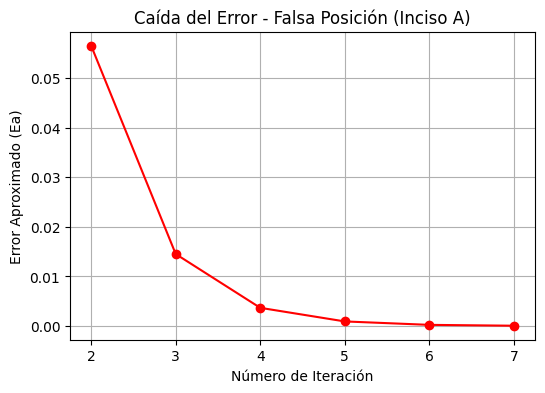


--------------------------------------------------
Iniciando Falsa Posición: Inciso B
--------------------------------------------------
Iteracion 1: Raíz calculada = 0.157187 | Error = 100.000000
Iteracion 2: Raíz calculada = 0.266512 | Error = 0.410205
Iteracion 3: Raíz calculada = 0.339425 | Error = 0.214814
Iteracion 4: Raíz calculada = 0.386405 | Error = 0.121582
Iteracion 5: Raíz calculada = 0.415910 | Error = 0.070943
Iteracion 6: Raíz calculada = 0.434118 | Error = 0.041942
Iteracion 7: Raíz calculada = 0.445225 | Error = 0.024948
Iteracion 8: Raíz calculada = 0.451952 | Error = 0.014884
Iteracion 9: Raíz calculada = 0.456008 | Error = 0.008893

--> RAÍZ FINAL APROXIMADA PARA Inciso B: 0.456008


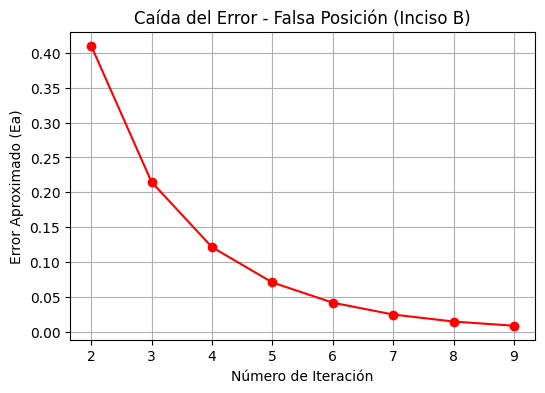


--------------------------------------------------
Iniciando Falsa Posición: Inciso C
--------------------------------------------------
Iteracion 1: Raíz calculada = 6.275862 | Error = 100.000000
Iteracion 2: Raíz calculada = 6.533873 | Error = 0.039488
Iteracion 3: Raíz calculada = 6.576937 | Error = 0.006548

--> RAÍZ FINAL APROXIMADA PARA Inciso C: 6.576937


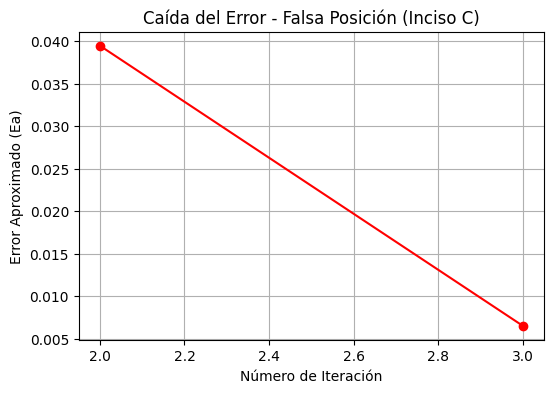


--------------------------------------------------
Iniciando Falsa Posición: Inciso D
--------------------------------------------------
Iteracion 1: Raíz calculada = 0.055556 | Error = 100.000000
Iteracion 2: Raíz calculada = 0.109834 | Error = 0.494187
Iteracion 3: Raíz calculada = 0.162401 | Error = 0.323685
Iteracion 4: Raíz calculada = 0.212889 | Error = 0.237157
Iteracion 5: Raíz calculada = 0.261002 | Error = 0.184339
Iteracion 6: Raíz calculada = 0.306512 | Error = 0.148476
Iteracion 7: Raíz calculada = 0.349257 | Error = 0.122389
Iteracion 8: Raíz calculada = 0.389139 | Error = 0.102487
Iteracion 9: Raíz calculada = 0.426115 | Error = 0.086775
Iteracion 10: Raíz calculada = 0.460194 | Error = 0.074054
Iteracion 11: Raíz calculada = 0.491428 | Error = 0.063558
Iteracion 12: Raíz calculada = 0.519907 | Error = 0.054776
Iteracion 13: Raíz calculada = 0.545746 | Error = 0.047348
Iteracion 14: Raíz calculada = 0.569087 | Error = 0.041014
Iteracion 15: Raíz calculada = 0.590084 | E

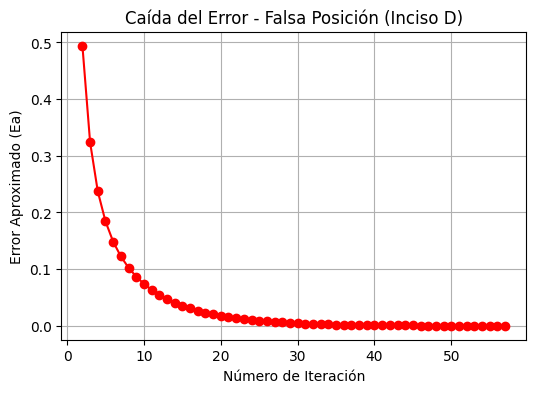

In [8]:
import math
import matplotlib.pyplot as plt

# 1.-Definimos las funciones solicitadas
def funcion_a(x):
    return (x**3) + 4*(x**2) - 10.0

def funcion_b(x):
    return math.exp(3*x) - 4.0

def funcion_c(x):
    return -0.4*(x**2) + 2.3*x + 2.2

def funcion_d(x):
    return (x**4) + 3*(x**2) - 2.0


# 2.-Método de Falsa Posición
def ejecutar_falsa_posicion(funcion_evaluar, Limite_Inferior, Limite_Superior, Error_Esperado, Nombre_Inciso):
    print(f"\n--------------------------------------------------")
    print(f"Iniciando Falsa Posición: {Nombre_Inciso}")
    print(f"--------------------------------------------------")

    Error_Actual = 100.0  # Valor inicial forzado para entrar al loop
    Punto_Calculado_Pasado = 0.0
    Iteracion = 1

    # Listas para guardar la información que irá a las gráficas
    Historial_Iteraciones = []
    Historial_Errores = []

    while Error_Actual > Error_Esperado:
        Funcion_Evaluada_Inferior = funcion_evaluar(Limite_Inferior)
        Funcion_Evaluada_Superior = funcion_evaluar(Limite_Superior)

        # Checamos que no nos de cero abajo
        Denominador = Funcion_Evaluada_Inferior - Funcion_Evaluada_Superior
        if Denominador == 0:
            print("Error: Denominador cero detectad")
            break

        # Aplicamos la fórmula de falsa posición
        Punto_Falso = Limite_Superior - (Funcion_Evaluada_Superior * (Limite_Inferior - Limite_Superior)) / Denominador
        Funcion_Evaluada_Falso = funcion_evaluar(Punto_Falso)

        # Comparamos este nuevo punto con el de la iteración pasada (Error Relativo)
        if Iteracion > 1:
            Error_Actual = abs((Punto_Falso - Punto_Calculado_Pasado) / Punto_Falso)

        # Guardamos datos para la gráfica (en iteración 1 el error es 100%, evitamos graficar ese pico)
        if Iteracion > 1:
            Historial_Iteraciones.append(Iteracion)
            Historial_Errores.append(Error_Actual)

        print(f"Iteracion {Iteracion}: Raíz calculada = {Punto_Falso:.6f} | Error = {Error_Actual:.6f}")

        # Descartamos la parte inútil del intervalo
        if (Funcion_Evaluada_Inferior * Funcion_Evaluada_Falso) < 0:
            Limite_Superior = Punto_Falso    # La raíz está en la izquierda
        elif (Funcion_Evaluada_Inferior * Funcion_Evaluada_Falso) > 0:
            Limite_Inferior = Punto_Falso    # La raíz está en la derecha
        else:
            Error_Actual = 0.0               # Le dimos a la raíz exacta por accidente

        Punto_Calculado_Pasado = Punto_Falso
        Iteracion = Iteracion + 1

        # Freno de emergencia por si el método se estanca
        if Iteracion > 100:
            print("Alerta: Se superaron las 100 iteraciones. Abortando ciclo.")
            break

    print(f"\n--> RAÍZ FINAL APROXIMADA PARA {Nombre_Inciso}: {Punto_Falso:.6f}")

    # ==========================================
    # 3.-Gráficas

    plt.figure(figsize=(6, 4))
    plt.plot(Historial_Iteraciones, Historial_Errores, marker='o', linestyle='-', color='r')
    plt.title(f"Caída del Error - Falsa Posición ({Nombre_Inciso})")
    plt.xlabel("Número de Iteración")
    plt.ylabel("Error Aproximado (Ea)")
    plt.grid(True)
    plt.show()


# 4. Ejecución en secuencia de los incisos

# Inciso a) Intervalo [1, 2], Ea = 0.0001
ejecutar_falsa_posicion(funcion_a, 1.0, 2.0, 0.0001, "Inciso A")

# Inciso b) Intervalo [0, 1], Ea = 0.01
ejecutar_falsa_posicion(funcion_b, 0.0, 1.0, 0.01, "Inciso B")

# Inciso c) Intervalo [5, 8], Ea = 3% (0.03 decimal)
ejecutar_falsa_posicion(funcion_c, 5.0, 8.0, 0.03, "Inciso C")

# Inciso d) Intervalo [0, 3], Ea = 0.0001
ejecutar_falsa_posicion(funcion_d, 0.0, 3.0, 0.0001, "Inciso D")